# Part 3: Advanced Model



In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report, confusion_matrix
)
import joblib
import os

## 1. Data Loading

In [3]:
# Load pre-split CSVs from Part 1
cols = ["content_clean", "type"]
train_df = pd.read_csv("processed_data/fakenews_995k_train.csv", usecols=cols)
val_df   = pd.read_csv("processed_data/fakenews_995k_val.csv",   usecols=cols)
test_df  = pd.read_csv("processed_data/fakenews_995k_test.csv",  usecols=cols)

for df in [train_df, val_df, test_df]:
    df["content_clean"] = df["content_clean"].fillna("")

print(f"Train : {len(train_df):>7,}")
print(f"Val   : {len(val_df):>7,}")
print(f"Test  : {len(test_df):>7,}")

Train : 795,866
Val   :  99,467
Test  :  99,667


## 2. Label Binarization

In [16]:
# 1 = reliable,  0 = fake
fake_types     = {"fake", "conspiracy",
                  "junksci", "rumor", "clickbait", "unreliable"}
reliable_types = {"reliable"}
keep_types     = fake_types | reliable_types

def binarize(df):
    df = df[df["type"].isin(keep_types)].copy()
    df["label"] = (df["type"] == "reliable").astype(int)
    return df

train_df = binarize(train_df)
val_df   = binarize(val_df)
test_df  = binarize(test_df)

print(f"Rows after filtering — Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}")
print(f"\nTrain class balance:")
print(train_df["label"].value_counts(normalize=True).rename({1: "reliable", 0: "fake"}).round(3))

Rows after filtering — Train: 442,640  Val: 55,737  Test: 55,613

Train class balance:
label
fake        0.606
reliable    0.394
Name: proportion, dtype: float64


## 3. Hyperparameter Tuning

In [17]:
# Grid search over max_features (TF-IDF vocabulary size) and alpha (regularisation strength)
# For each max_features value TF-IDF is fitted once; alpha is varied without refitting
max_features_grid = [10_000, 25_000, 50_000, 75_000]
alpha_grid        = [1e-5, 1e-4, 1e-3, 1e-2]

results = []
best_f1     = -1 
best_params = {}

for max_f in max_features_grid:
    vec  = TfidfVectorizer(max_features=max_f, sublinear_tf=True)
    X_tr = vec.fit_transform(train_df["content_clean"])
    X_v  = vec.transform(val_df["content_clean"])

    for alpha in alpha_grid:
        clf_tmp = SGDClassifier(loss="hinge", penalty="l2", alpha=alpha,
                                max_iter=100, random_state=42, n_jobs=-1)
        clf_tmp.fit(X_tr, train_df["label"].values)
        f1 = f1_score(val_df["label"].values, clf_tmp.predict(X_v), average="weighted")
        results.append({"max_features": max_f, "alpha": alpha, "val_f1": f1})
        print(f"max_features={max_f:>6,}  alpha={alpha:.0e}  →  weighted F1: {f1:.4f}")

        if f1 > best_f1:
            best_f1     = f1
            best_params = {"max_features": max_f, "alpha": alpha}

print(f"\nBest: max_features={best_params['max_features']:,}  alpha={best_params['alpha']:.0e}  →  F1: {best_f1:.4f}")

max_features=10,000  alpha=1e-05  →  weighted F1: 0.9548
max_features=10,000  alpha=1e-04  →  weighted F1: 0.9442
max_features=10,000  alpha=1e-03  →  weighted F1: 0.8891
max_features=10,000  alpha=1e-02  →  weighted F1: 0.5855
max_features=25,000  alpha=1e-05  →  weighted F1: 0.9590
max_features=25,000  alpha=1e-04  →  weighted F1: 0.9450
max_features=25,000  alpha=1e-03  →  weighted F1: 0.8765
max_features=25,000  alpha=1e-02  →  weighted F1: 0.4798
max_features=50,000  alpha=1e-05  →  weighted F1: 0.9599
max_features=50,000  alpha=1e-04  →  weighted F1: 0.9448
max_features=50,000  alpha=1e-03  →  weighted F1: 0.8690
max_features=50,000  alpha=1e-02  →  weighted F1: 0.4609
max_features=75,000  alpha=1e-05  →  weighted F1: 0.9600
max_features=75,000  alpha=1e-04  →  weighted F1: 0.9445
max_features=75,000  alpha=1e-03  →  weighted F1: 0.8655
max_features=75,000  alpha=1e-02  →  weighted F1: 0.4570

Best: max_features=75,000  alpha=1e-05  →  F1: 0.9600


## 4. TF-IDF Vectorization

In [18]:
# Refit final vectorizer and transform all splits using the best max_features from tuning
vectorizer = TfidfVectorizer(max_features=best_params["max_features"], sublinear_tf=True)

X_train = vectorizer.fit_transform(train_df["content_clean"])
X_val   = vectorizer.transform(val_df["content_clean"])
X_test  = vectorizer.transform(test_df["content_clean"])

y_train = train_df["label"].values
y_val   = val_df["label"].values
y_test  = test_df["label"].values

print(f"TF-IDF feature matrix: {X_train.shape}")

TF-IDF feature matrix: (442640, 75000)


## 5. Model Training — Linear SVM (SGD)

In [19]:
# SGDClassifier with hinge loss = linear SVM, using best alpha from tuning
clf = SGDClassifier(
    loss="hinge",
    penalty="l2",
    alpha=best_params["alpha"],
    max_iter=100,
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train, y_train)
print("Training complete.")
print(f"  max_features : {best_params['max_features']:,}")
print(f"  alpha        : {best_params['alpha']:.0e}")

Training complete.
  max_features : 75,000
  alpha        : 1e-05


## 6. Evaluation on Validation Set

=== Validation Set Performance ===
Accuracy : 0.9601
F1 (weighted) : 0.9600
F1 (macro)    : 0.9582

              precision    recall  f1-score   support

        fake       0.96      0.98      0.97     33425
    reliable       0.97      0.93      0.95     22312

    accuracy                           0.96     55737
   macro avg       0.96      0.96      0.96     55737
weighted avg       0.96      0.96      0.96     55737



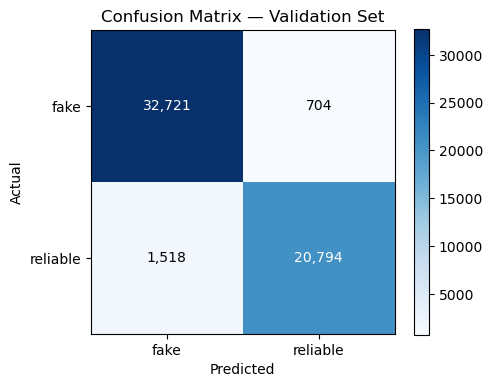

In [20]:
y_pred_val = clf.predict(X_val)

print("=== Validation Set Performance ===")
print(f"Accuracy : {accuracy_score(y_val, y_pred_val):.4f}")
print(f"F1 (weighted) : {f1_score(y_val, y_pred_val, average='weighted'):.4f}")
print(f"F1 (macro)    : {f1_score(y_val, y_pred_val, average='macro'):.4f}")
print()
print(classification_report(y_val, y_pred_val, target_names=["fake", "reliable"]))

# Confusion matrix
cm = confusion_matrix(y_val, y_pred_val)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["fake", "reliable"])
ax.set_yticklabels(["fake", "reliable"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Validation Set")
plt.colorbar(im); plt.tight_layout(); plt.show()

## 7. Save Model for Part 4

In [21]:
os.makedirs("models", exist_ok=True)
joblib.dump(clf,        "models/sgd_svm.pkl")
joblib.dump(vectorizer, "models/tfidf_vectorizer.pkl")
print("Saved: models/sgd_svm.pkl")
print("Saved: models/tfidf_vectorizer.pkl")

Saved: models/sgd_svm.pkl
Saved: models/tfidf_vectorizer.pkl
